# Sobolev loss on synthetic squares

Build two synthetic single-channel "planes":

* **A** — a square at the centre of the plane (the *target*).
* **B(D)** — the same square shifted by `D` pixels horizontally (positive `D` → right, negative `D` → left).

Then compute the per-plane Sobolev loss `sobolev_loss_single(A, B(D), W)` for several values of
`SOBOLEV_MAX_PAD`. The plot of `D vs L(D)` lets you read off the effective gradient reach of the
loss at each padding choice (screening length `L = max_pad / 2`).

## Why this matters

The H^{-s} Sobolev kernel decays in real space as `exp(-r/L)`. So:
* For `|D| ≪ L` the loss grows ~quadratically with `D` (constant gradient).
* For `|D| ≳ L` the gradient decays exponentially and the loss flattens.
* Beyond `~max_pad` the FFT pad runs out — kernel can't reach further at all.

This is the synthetic counterpart to the velocity-induced time shifts that `run_optimization.py`
tries to fit: with the production setting `SOBOLEV_MAX_PAD=128` (so `L=64 px`) the loss is
essentially blind to displacements larger than a few hundred pixels.

In [1]:
import sys; sys.path.insert(0, '..')

import math

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from tools.losses import make_sobolev_weight, sobolev_loss_single

print(f'JAX devices: {jax.devices()}')

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/gregor/JAXTPC/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/gregor/JAXTPC/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/home/gregor/JAXTPC/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:134: operation cuInit(0) failed: Unknown CUDA error 100; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


JAX devices: [CpuDevice(id=0)]


## Synthetic plane factory

We use a moderate plane size (`H × W = 512 × 1024`) so the runtime is reasonable on CPU yet large
enough to fit big paddings (`max_pad` up to a few hundred) without the pad eating the whole plane.
The square is `SQUARE_SIZE = 16 px` on a side and unit-amplitude.

Key invariant: `B(D)` always has the same total mass `∑|B|` regardless of `D`, so the
normalisation `(A - B) / ∑|B|` inside `sobolev_loss_single` doesn't change with `D`. Any change
in `L(D)` therefore comes purely from the *spatial structure* of the residual.

In [2]:
PLANE_H = 512
PLANE_W = 1024
SQUARE_SIZE = 16


def make_square_plane(H, W, square_size, dx=0, dy=0, amplitude=1.0):
    """Plane of zeros with a `square_size`-by-`square_size` block of `amplitude`.

    The block is centred at (H//2 + dy, W//2 + dx). The block is clipped to the
    plane bounds — when it falls fully outside the plane the result is zeros
    (and ∑|B| = 0, which we never actually evaluate the loss on).
    """
    plane = np.zeros((H, W), dtype=np.float32)
    half = square_size // 2
    cy = H // 2 + dy
    cx = W // 2 + dx
    y0, y1 = max(0, cy - half), min(H, cy + half)
    x0, x1 = max(0, cx - half), min(W, cx + half)
    if y0 < y1 and x0 < x1:
        plane[y0:y1, x0:x1] = amplitude
    return jnp.asarray(plane)


A = make_square_plane(PLANE_H, PLANE_W, SQUARE_SIZE, dx=0)
print(f'A shape: {A.shape}, sum|A| = {float(jnp.sum(jnp.abs(A))):.3f}')

A shape: (512, 1024), sum|A| = 256.000


## Preview the planes for a few `D` values

Top row: prediction `B(D)`. Bottom row: residual `A − B(D)`. The displacement `D` is in
*pixels*, so directly comparable to `max_pad` and the screening length `L = max_pad/2`.

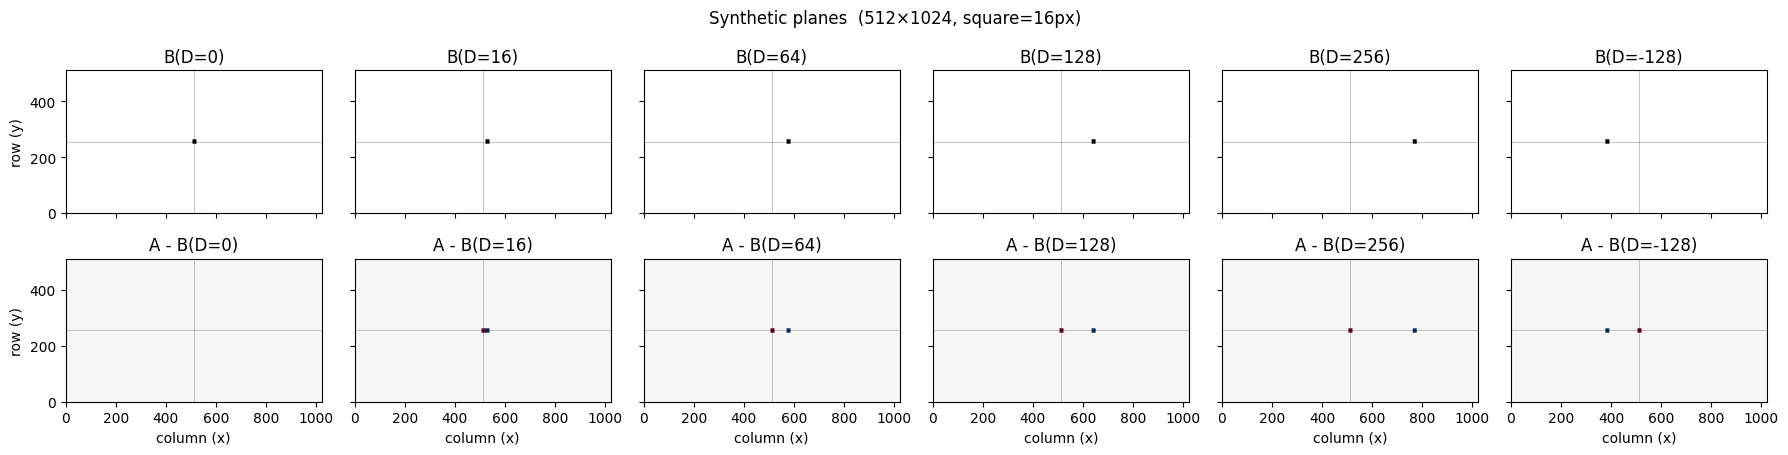

In [3]:
preview_Ds = [0, 16, 64, 128, 256, -128]

fig, axes = plt.subplots(2, len(preview_Ds), figsize=(3.0 * len(preview_Ds), 4.6),
                          sharex=True, sharey=True)

for i, D in enumerate(preview_Ds):
    B = make_square_plane(PLANE_H, PLANE_W, SQUARE_SIZE, dx=D)
    diff = np.asarray(A) - np.asarray(B)
    axes[0, i].imshow(np.asarray(B), origin='lower', cmap='Greys',
                       vmin=0, vmax=1, aspect='auto')
    axes[0, i].set_title(f'B(D={D})')
    axes[1, i].imshow(diff, origin='lower', cmap='RdBu_r',
                       vmin=-1, vmax=1, aspect='auto')
    axes[1, i].set_title(f'A - B(D={D})')
    for ax in axes[:, i]:
        ax.axvline(PLANE_W // 2, color='k', lw=0.4, alpha=0.4)
        ax.axhline(PLANE_H // 2, color='k', lw=0.4, alpha=0.4)

axes[0, 0].set_ylabel('row (y)')
axes[1, 0].set_ylabel('row (y)')
for ax in axes[1, :]:
    ax.set_xlabel('column (x)')

fig.suptitle(f'Synthetic planes  ({PLANE_H}×{PLANE_W}, square={SQUARE_SIZE}px)')
fig.tight_layout()
plt.show()

## Loss vs displacement, for several `max_pad` values

We sweep `D` from `-PLANE_W//2` to `+PLANE_W//2` and evaluate `sobolev_loss_single(A, B(D), W)`
for several `max_pad` settings. The default Sobolev exponent `s=2` is used (this is what
`run_optimization.py` uses).

The `max_pad` values span:
* `max_pad = 32, 64`  — *smaller* than the production setting (very local).
* `max_pad = 128`     — current production value (`SOBOLEV_MAX_PAD` in `run_optimization.py`).
* `max_pad = 256, 512` — *larger* paddings, useful if you want longer-range gradient pull.

The dashed vertical lines mark each setting's screening length `L = max_pad/2`.

In [4]:
max_pads = [32, 64, 128, 256, 512]
Ds = np.arange(-PLANE_W // 2, PLANE_W // 2 + 1, 4)
assert 0 in Ds, 'sweep must include D=0 for the zero-loss reference'
zero_idx = int(np.where(Ds == 0)[0][0])

weights_by_pad = {
    mp: make_sobolev_weight(PLANE_H, PLANE_W, max_pad=mp, s=2.0)
    for mp in max_pads
}

loss_fn = jax.jit(sobolev_loss_single)

losses_by_pad = {}
for mp in max_pads:
    W_mp = weights_by_pad[mp]
    out = []
    for D in Ds:
        B = make_square_plane(PLANE_H, PLANE_W, SQUARE_SIZE, dx=int(D))
        if float(jnp.sum(jnp.abs(B))) == 0.0:
            out.append(np.nan)
            continue
        out.append(float(loss_fn(A, B, W_mp)))
    losses_by_pad[mp] = np.asarray(out)
    L_idx = int(np.argmin(np.abs(Ds - mp // 2)))
    print(f'max_pad={mp:4d}  L={mp//2:4d} px  '
          f'L(D=0)={losses_by_pad[mp][zero_idx]:.3e}  '
          f'L(|D|=L)~{losses_by_pad[mp][L_idx]:.3e}')

max_pad=  32  L=  16 px  L(D=0)=0.000e+00  L(|D|=L)~1.506e+04


max_pad=  64  L=  32 px  L(D=0)=0.000e+00  L(|D|=L)~8.422e+04


max_pad= 128  L=  64 px  L(D=0)=0.000e+00  L(|D|=L)~3.805e+05


max_pad= 256  L= 128 px  L(D=0)=0.000e+00  L(|D|=L)~1.587e+06


max_pad= 512  L= 256 px  L(D=0)=0.000e+00  L(|D|=L)~6.430e+06


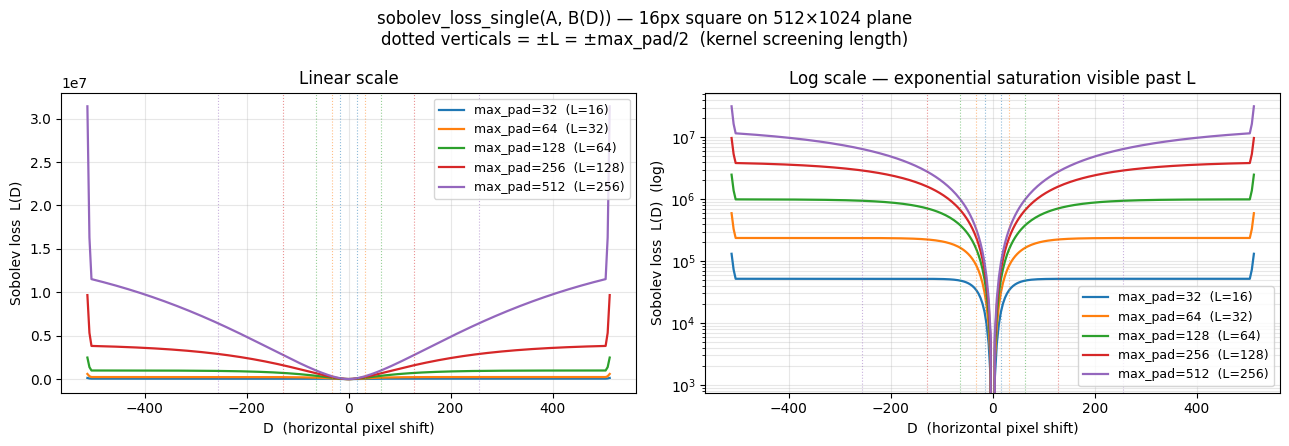

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for mp in max_pads:
    label = f'max_pad={mp}  (L={mp//2})'
    axes[0].plot(Ds, losses_by_pad[mp], label=label, lw=1.6)
    axes[1].plot(Ds, losses_by_pad[mp], label=label, lw=1.6)

for mp in max_pads:
    L = mp / 2.0
    for ax in axes:
        ax.axvline( L, ls=':', lw=0.8, alpha=0.5, color=f'C{max_pads.index(mp)}')
        ax.axvline(-L, ls=':', lw=0.8, alpha=0.5, color=f'C{max_pads.index(mp)}')

axes[0].set_xlabel('D  (horizontal pixel shift)')
axes[0].set_ylabel('Sobolev loss  L(D)')
axes[0].set_title('Linear scale')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_yscale('log')
axes[1].set_xlabel('D  (horizontal pixel shift)')
axes[1].set_ylabel('Sobolev loss  L(D)  (log)')
axes[1].set_title('Log scale — exponential saturation visible past L')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3, which='both')

fig.suptitle(f'sobolev_loss_single(A, B(D)) — {SQUARE_SIZE}px square on {PLANE_H}×{PLANE_W} plane\n'
             f'dotted verticals = ±L = ±max_pad/2  (kernel screening length)')
fig.tight_layout()
plt.show()

## Gradient w.r.t. `D`

Because the optimizer only uses the *gradient* of the loss, the more honest diagnostic is
`dL/dD`. We approximate it by central differences over the curves above (the analytic gradient
is straightforward but noisier to plot at this resolution since `D` is integer-valued).

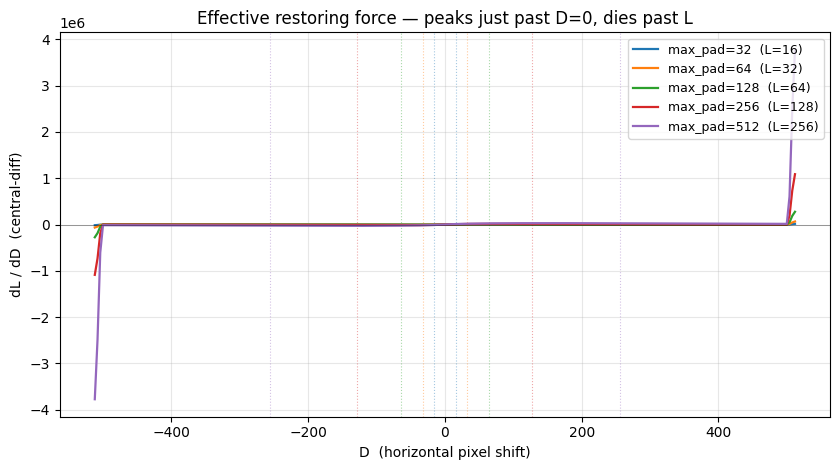

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

dD = float(Ds[1] - Ds[0])
for mp in max_pads:
    losses = losses_by_pad[mp]
    grad = np.gradient(losses, dD)
    ax.plot(Ds, grad, lw=1.6, label=f'max_pad={mp}  (L={mp//2})')
    L = mp / 2.0
    ax.axvline( L, ls=':', lw=0.8, alpha=0.4, color=f'C{max_pads.index(mp)}')
    ax.axvline(-L, ls=':', lw=0.8, alpha=0.4, color=f'C{max_pads.index(mp)}')

ax.axhline(0, color='k', lw=0.5, alpha=0.5)
ax.set_xlabel('D  (horizontal pixel shift)')
ax.set_ylabel('dL / dD  (central-diff)')
ax.set_title('Effective restoring force — peaks just past D=0, dies past L')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Vertical shift

Same exercise but the square is shifted *vertically* (`Dy`) instead of horizontally. With
`PLANE_H = 512` the vertical extent is half the horizontal one, so this also stress-tests what
happens when the kernel screening length `L = max_pad/2` becomes comparable to the plane size
itself (e.g. `max_pad=512` ⇒ `L=256 px ≈ PLANE_H/2`).

Three plots, mirroring the horizontal section: plane previews, `L(Dy)` vs `Dy`, and `dL/dDy`.

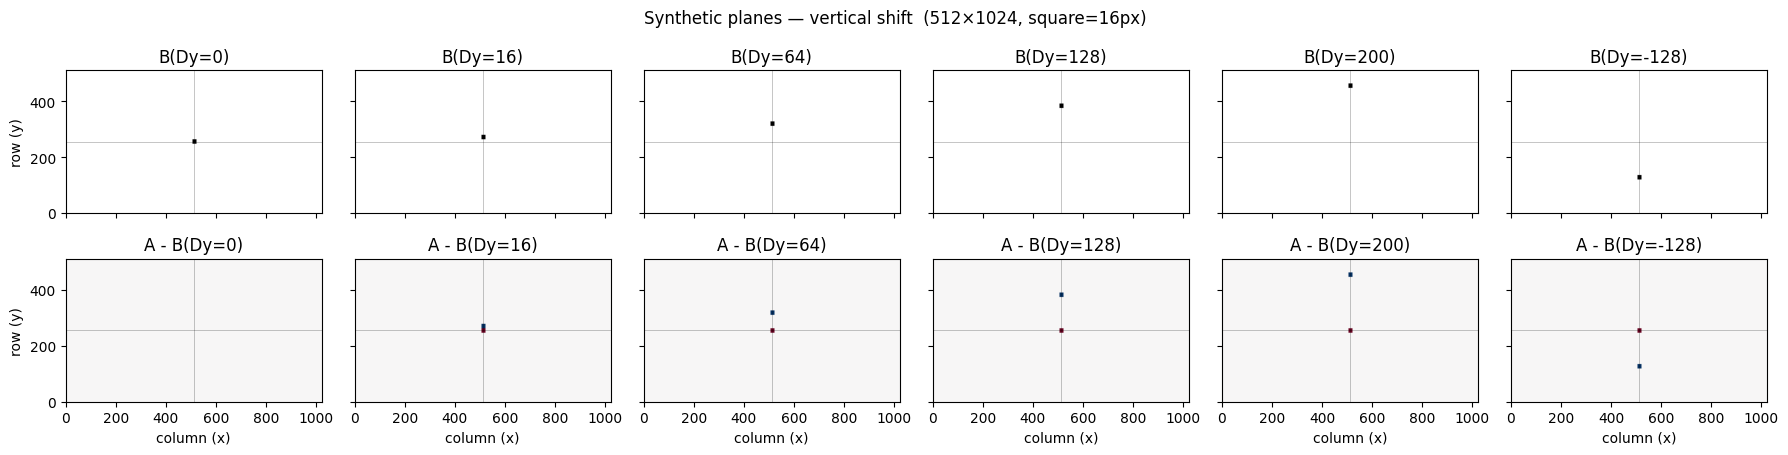

In [7]:
preview_Dys = [0, 16, 64, 128, 200, -128]

fig, axes = plt.subplots(2, len(preview_Dys), figsize=(3.0 * len(preview_Dys), 4.6),
                          sharex=True, sharey=True)

for i, Dy in enumerate(preview_Dys):
    B = make_square_plane(PLANE_H, PLANE_W, SQUARE_SIZE, dy=Dy)
    diff = np.asarray(A) - np.asarray(B)
    axes[0, i].imshow(np.asarray(B), origin='lower', cmap='Greys',
                       vmin=0, vmax=1, aspect='auto')
    axes[0, i].set_title(f'B(Dy={Dy})')
    axes[1, i].imshow(diff, origin='lower', cmap='RdBu_r',
                       vmin=-1, vmax=1, aspect='auto')
    axes[1, i].set_title(f'A - B(Dy={Dy})')
    for ax in axes[:, i]:
        ax.axvline(PLANE_W // 2, color='k', lw=0.4, alpha=0.4)
        ax.axhline(PLANE_H // 2, color='k', lw=0.4, alpha=0.4)

axes[0, 0].set_ylabel('row (y)')
axes[1, 0].set_ylabel('row (y)')
for ax in axes[1, :]:
    ax.set_xlabel('column (x)')

fig.suptitle(f'Synthetic planes — vertical shift  ({PLANE_H}×{PLANE_W}, square={SQUARE_SIZE}px)')
fig.tight_layout()
plt.show()

In [8]:
Dys = np.arange(-PLANE_H // 2, PLANE_H // 2 + 1, 4)
assert 0 in Dys, 'sweep must include Dy=0 for the zero-loss reference'
zero_idx_y = int(np.where(Dys == 0)[0][0])

losses_by_pad_y = {}
for mp in max_pads:
    W_mp = weights_by_pad[mp]
    out = []
    for Dy in Dys:
        B = make_square_plane(PLANE_H, PLANE_W, SQUARE_SIZE, dy=int(Dy))
        if float(jnp.sum(jnp.abs(B))) == 0.0:
            out.append(np.nan)
            continue
        out.append(float(loss_fn(A, B, W_mp)))
    losses_by_pad_y[mp] = np.asarray(out)
    L_idx_y = int(np.argmin(np.abs(Dys - mp // 2)))
    print(f'max_pad={mp:4d}  L={mp//2:4d} px  '
          f'L(Dy=0)={losses_by_pad_y[mp][zero_idx_y]:.3e}  '
          f'L(|Dy|=L)~{losses_by_pad_y[mp][L_idx_y]:.3e}')

max_pad=  32  L=  16 px  L(Dy=0)=0.000e+00  L(|Dy|=L)~1.506e+04


max_pad=  64  L=  32 px  L(Dy=0)=0.000e+00  L(|Dy|=L)~8.422e+04


max_pad= 128  L=  64 px  L(Dy=0)=0.000e+00  L(|Dy|=L)~3.805e+05


max_pad= 256  L= 128 px  L(Dy=0)=0.000e+00  L(|Dy|=L)~1.582e+06


max_pad= 512  L= 256 px  L(Dy=0)=0.000e+00  L(|Dy|=L)~2.070e+07


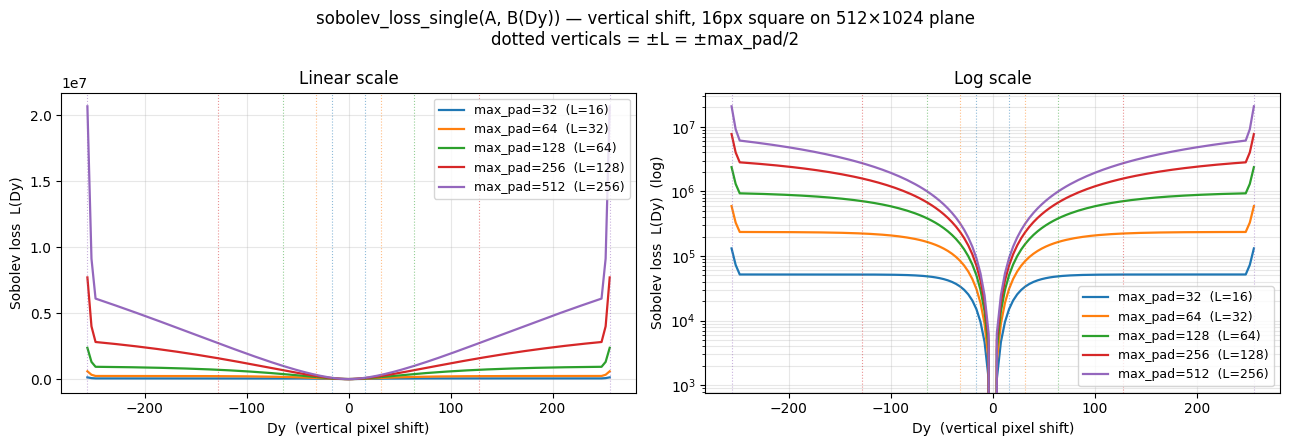

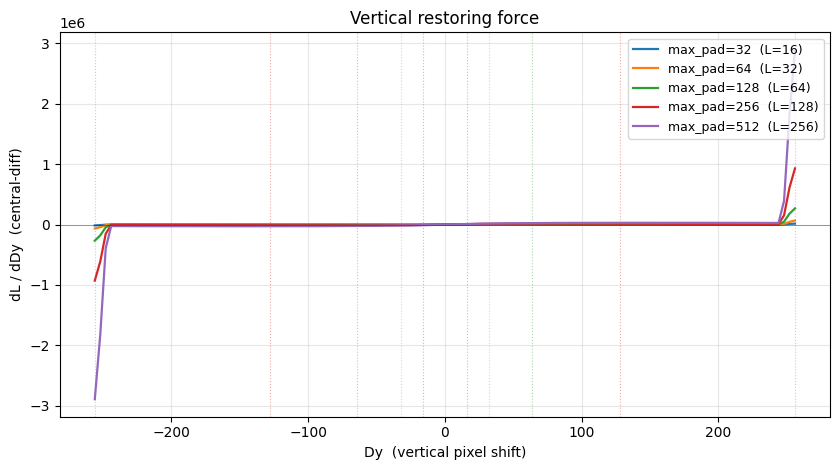

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for mp in max_pads:
    label = f'max_pad={mp}  (L={mp//2})'
    axes[0].plot(Dys, losses_by_pad_y[mp], label=label, lw=1.6)
    axes[1].plot(Dys, losses_by_pad_y[mp], label=label, lw=1.6)

for mp in max_pads:
    L = mp / 2.0
    for ax in axes:
        ax.axvline( L, ls=':', lw=0.8, alpha=0.5, color=f'C{max_pads.index(mp)}')
        ax.axvline(-L, ls=':', lw=0.8, alpha=0.5, color=f'C{max_pads.index(mp)}')

axes[0].set_xlabel('Dy  (vertical pixel shift)')
axes[0].set_ylabel('Sobolev loss  L(Dy)')
axes[0].set_title('Linear scale')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_yscale('log')
axes[1].set_xlabel('Dy  (vertical pixel shift)')
axes[1].set_ylabel('Sobolev loss  L(Dy)  (log)')
axes[1].set_title('Log scale')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3, which='both')

fig.suptitle(f'sobolev_loss_single(A, B(Dy)) — vertical shift, {SQUARE_SIZE}px square on '
             f'{PLANE_H}×{PLANE_W} plane\ndotted verticals = ±L = ±max_pad/2')
fig.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8.5, 4.8))

dDy = float(Dys[1] - Dys[0])
for mp in max_pads:
    losses = losses_by_pad_y[mp]
    grad = np.gradient(losses, dDy)
    ax.plot(Dys, grad, lw=1.6, label=f'max_pad={mp}  (L={mp//2})')
    L = mp / 2.0
    ax.axvline( L, ls=':', lw=0.8, alpha=0.4, color=f'C{max_pads.index(mp)}')
    ax.axvline(-L, ls=':', lw=0.8, alpha=0.4, color=f'C{max_pads.index(mp)}')

ax.axhline(0, color='k', lw=0.5, alpha=0.5)
ax.set_xlabel('Dy  (vertical pixel shift)')
ax.set_ylabel('dL / dDy  (central-diff)')
ax.set_title('Vertical restoring force')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Takeaways

* **Loss saturates past `|D| ≳ L = max_pad/2`.** The kernel decays as `exp(-r/L)`; once the
  prediction is more than a few `L` away from the target, the gradient is essentially gone.
* **The horizontal and vertical curves are essentially identical** wherever the shift fits
  comfortably inside the plane — the kernel is isotropic in pixel units. They diverge only
  near the plane boundary, where part of the shifted square clips out of the plane and
  `∑|B|` (the loss-internal normalisation) drops, distorting the curve. The `max_pad=512`
  vertical case shows this clearly: at `|Dy| ≳ 240 px` the square starts running off the
  edge.
* **`dL/dD` peaks at small `|D|` and decays exponentially.** That's the "strong-pull" regime.
* **`max_pad` is the only knob** that controls reach. Doubling `max_pad` doubles `L` *and*
  doubles the FFT padding (so cost grows ~linearly in each axis). Quadrupling the DC weight
  as a side-effect is what gives Sobolev its long-range character.
* **For the production optimization** with `SOBOLEV_MAX_PAD = 128` the strong-pull regime
  ends at `|D| ~ 64 px`. If a parameter (e.g. `velocity_cm_us`) shifts the predicted signal
  further than that, you'll see exactly the saturation curve above — symptom: loss looks
  flat / grad is tiny even though the prediction is visibly off.